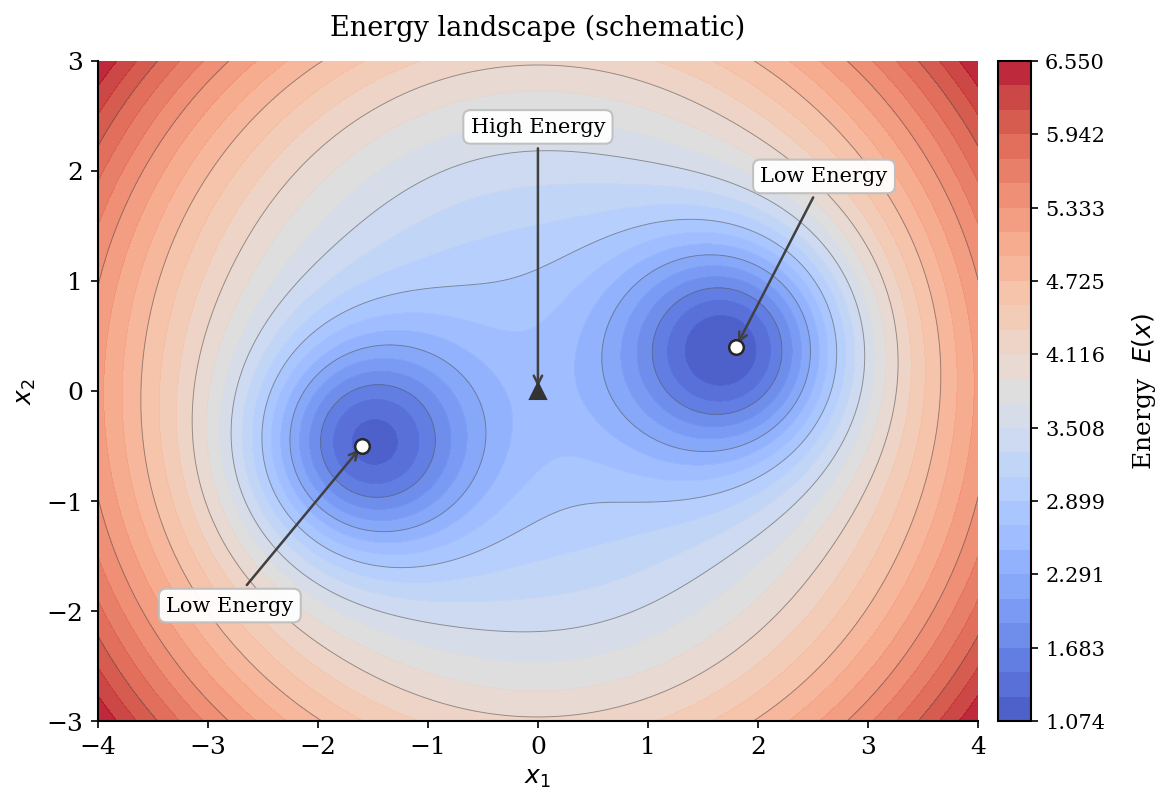

In [2]:
"""Energy landscape: two low-energy valleys (high probability) and intervening peaks."""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# Presentation style
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Grid
x = np.linspace(-4, 4, 400)
y = np.linspace(-3, 3, 300)
X, Y = np.meshgrid(x, y)

# Smooth bimodal energy: two Gaussian wells + mild background curvature
# Low E at valleys → high probability under p(x) ∝ exp(-E(x))
E = (
    0.15 * (X**2 + Y**2)
    + 2.8
    - 2.2 * np.exp(-((X - 1.8) ** 2 + (Y - 0.4) ** 2) / 1.1)
    - 2.0 * np.exp(-((X + 1.6) ** 2 + (Y + 0.5) ** 2) / 1.0)
)

# Valley and peak locations (approximate minima / saddle between wells)
valley_1 = (1.8, 0.4)
valley_2 = (-1.6, -0.5)
peak = (0.0, 0.0)

fig, ax = plt.subplots(figsize=(8, 5.5), dpi=150)

levels = np.linspace(E.min(), E.max(), 28)
cf = ax.contourf(X, Y, E, levels=levels, cmap=cm.coolwarm, alpha=0.92)
cs = ax.contour(X, Y, E, levels=levels[::3], colors="0.35", linewidths=0.45, alpha=0.6)

cbar = fig.colorbar(cf, ax=ax, pad=0.02, fraction=0.046)
cbar.set_label("Energy  $E(x)$", rotation=90, labelpad=12)
cbar.ax.tick_params(labelsize=10)

# Mark extrema
ax.plot(*valley_1, "o", color="white", markersize=7, markeredgecolor="0.15", markeredgewidth=1.2, zorder=5)
ax.plot(*valley_2, "o", color="white", markersize=7, markeredgecolor="0.15", markeredgewidth=1.2, zorder=5)
ax.plot(*peak, "^", color="0.2", markersize=8, zorder=5)

# Annotations
bbox = dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="0.75", alpha=0.95)
ax.annotate(
    "Low Energy",
    xy=valley_1,
    xytext=(2.6, 1.9),
    fontsize=10,
    ha="center",
    arrowprops=dict(arrowstyle="->", color="0.25", lw=1.2),
    bbox=bbox,
)
ax.annotate(
    "Low Energy",
    xy=valley_2,
    xytext=(-2.8, -2.0),
    fontsize=10,
    ha="center",
    arrowprops=dict(arrowstyle="->", color="0.25", lw=1.2),
    bbox=bbox,
)
ax.annotate(
    "High Energy",
    xy=peak,
    xytext=(0.0, 2.35),
    fontsize=10,
    ha="center",
    arrowprops=dict(arrowstyle="->", color="0.25", lw=1.2),
    bbox=bbox,
)

ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("Energy landscape (schematic)", pad=12)
ax.set_aspect("equal")
ax.set_xlim(-4, 4)
ax.set_ylim(-3, 3)

plt.tight_layout()
plt.savefig("../runs/energy_landscape.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

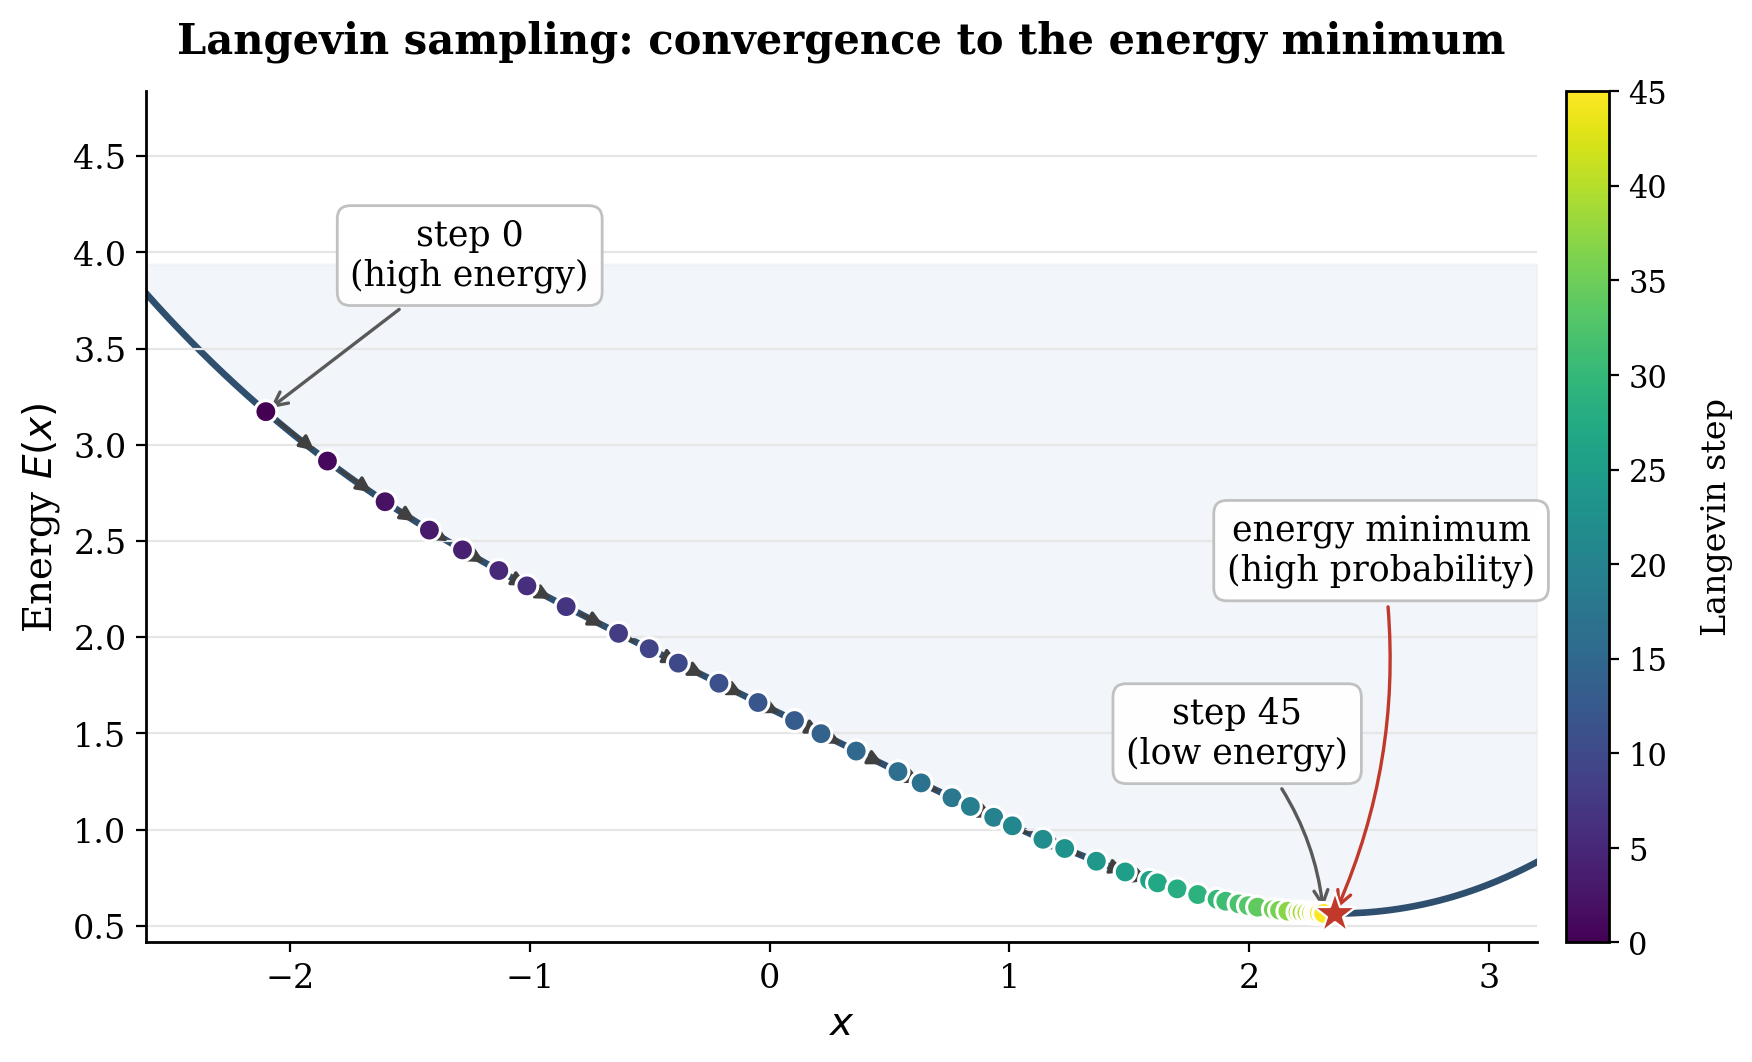

Final x = 2.310, minimum at x = 2.358 (Δ = 0.047)


In [8]:
"""1D energy landscape — Langevin trajectory converging to the energy minimum."""

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 13,
    "axes.labelsize": 14,
    "axes.titlesize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Smooth 1D energy with a clear minimum (schematic)
def energy(x: np.ndarray) -> np.ndarray:
    return 0.22 * (x - 1.4) ** 2 + 0.55 * np.cos(0.9 * x) + 0.65


def energy_grad(x: float) -> float:
    eps = 1e-5
    return float((energy(x + eps) - energy(x - eps)) / (2 * eps))


# True minimum of E(x) on the plotted domain (for reference marker)
x_grid_fine = np.linspace(-2.6, 3.2, 5000)
x_min = float(x_grid_fine[np.argmin(energy(x_grid_fine))])
e_min = float(energy(x_min))

# Langevin dynamics with annealed noise → converges near the minimum
rng = np.random.default_rng(7)
x_pos = -2.1
alpha = 0.24
sigma = 0.055
n_steps = 45

trajectory = [x_pos]
for t in range(n_steps):
    # less noise toward the end so the chain can settle in the valley
    noise_scale = sigma * (0.1 + 0.9 * (1.0 - t / max(n_steps - 1, 1)))
    x_pos = x_pos - alpha * energy_grad(x_pos) + noise_scale * rng.standard_normal()
    trajectory.append(x_pos)

trajectory = np.array(trajectory)
energies = energy(trajectory)

# Plot curve
x_grid = np.linspace(-2.6, 3.2, 500)
E_grid = energy(x_grid)

fig, ax = plt.subplots(figsize=(9.2, 5.6), dpi=200)
ax.fill_between(x_grid, E_grid, E_grid.max() + 0.15, color="#e8eef5", alpha=0.55, zorder=0)
ax.plot(x_grid, E_grid, color="#2f4f6f", linewidth=2.4, zorder=1)

# True minimum on the curve (reference)
ax.plot(
    x_min,
    e_min,
    marker="*",
    markersize=16,
    color="#c0392b",
    markeredgecolor="white",
    markeredgewidth=0.8,
    zorder=5,
)

# Sampling steps
ax.scatter(
    trajectory,
    energies,
    s=62,
    c=np.arange(len(trajectory)),
    cmap="viridis",
    edgecolors="white",
    linewidths=1.1,
    zorder=4,
)

# Arrows between consecutive steps
for i in range(len(trajectory) - 1):
    ax.annotate(
        "",
        xy=(trajectory[i + 1], energies[i + 1]),
        xytext=(trajectory[i], energies[i]),
        arrowprops=dict(
            arrowstyle="-|>",
            color="0.25",
            lw=1.2,
            shrinkA=6,
            shrinkB=6,
            mutation_scale=11,
        ),
        zorder=3,
    )

ann_fs = 12.5
bbox = dict(boxstyle="round,pad=0.38", facecolor="white", edgecolor="0.75", alpha=0.97)

# Left: keep text box inside the axes
ax.annotate(
    "step 0\n(high energy)",
    xy=(trajectory[0], energies[0]),
    xytext=(-1.25, energies[0] + 0.62),
    fontsize=ann_fs,
    ha="center",
    va="bottom",
    arrowprops=dict(arrowstyle="->", color="0.35", lw=1.2),
    bbox=bbox,
    clip_on=False,
)

# Right: final step (lower right) and true minimum (upper right) — no overlap
ax.annotate(
    f"step {n_steps}\n(low energy)",
    xy=(trajectory[-1], energies[-1]),
    xytext=(1.95, 1.5),
    fontsize=ann_fs,
    ha="center",
    va="center",
    arrowprops=dict(arrowstyle="->", color="0.35", lw=1.2, connectionstyle="arc3,rad=-0.18"),
    bbox=bbox,
    clip_on=False,
)
ax.annotate(
    "energy minimum\n(high probability)",
    xy=(x_min, e_min),
    xytext=(2.55, 2.45),
    fontsize=ann_fs,
    ha="center",
    va="center",
    arrowprops=dict(arrowstyle="->", color="#c0392b", lw=1.2, connectionstyle="arc3,rad=-0.15"),
    bbox=bbox,
    clip_on=False,
)

ax.set_xlabel("$x$")
ax.set_ylabel("Energy $E(x)$")
ax.set_title("Langevin sampling: convergence to the energy minimum", pad=14, fontweight="bold")
ax.set_xlim(-2.6, 3.2)
ax.set_ylim(E_grid.min() - 0.15, E_grid.max() + 1.05)
ax.grid(axis="y", color="0.9", linewidth=0.8, zorder=0)
ax.margins(x=0.02)

sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(0, n_steps))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02, fraction=0.035)
cbar.set_label("Langevin step", rotation=90, labelpad=12, fontsize=12)
cbar.ax.tick_params(labelsize=11)

fig.subplots_adjust(left=0.10, right=0.90, top=0.90, bottom=0.14)
plt.savefig("../runs/langevin_trajectory_1d.png", dpi=200, bbox_inches="tight", facecolor="white", pad_inches=0.08)
plt.show()

print(f"Final x = {trajectory[-1]:.3f}, minimum at x = {x_min:.3f} (Δ = {abs(trajectory[-1]-x_min):.3f})")

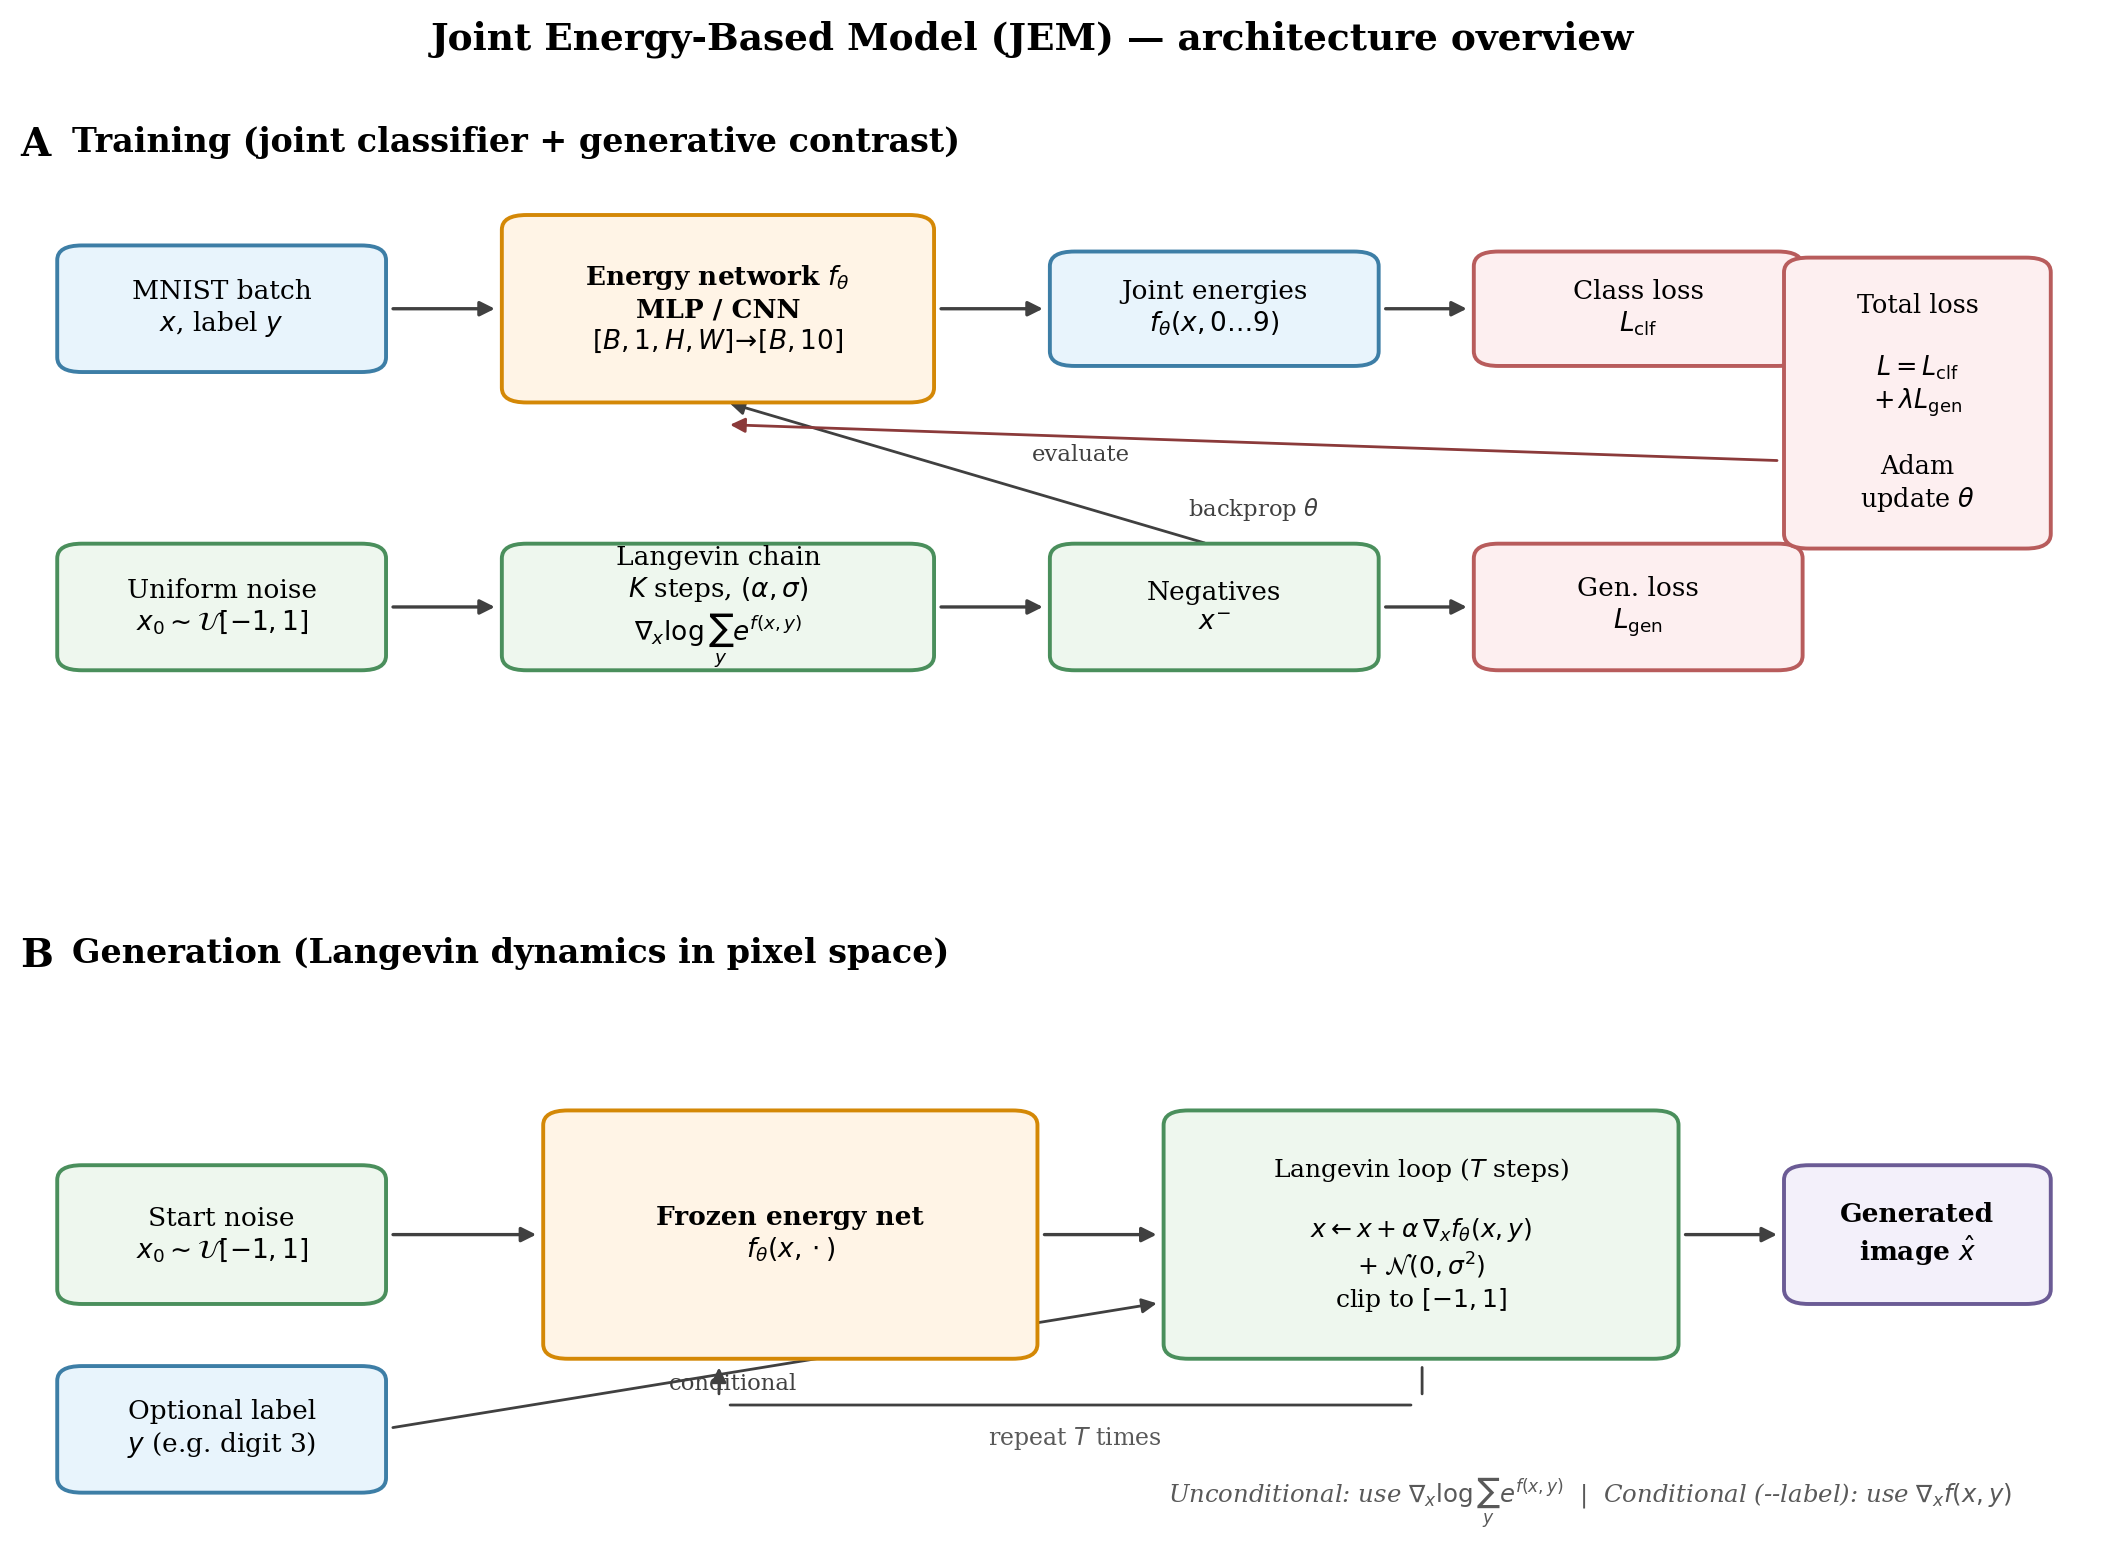

: 

In [ ]:
"""Publication-style architecture diagram for the joint EBM (ebm-digits)."""

from __future__ import annotations

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
})

# Palette
C_NET = "#fff4e6"
C_NET_E = "#d48806"
C_DATA = "#e8f4fc"
C_DATA_E = "#3d7ea6"
C_PROC = "#eef7ee"
C_PROC_E = "#4a8f5c"
C_LOSS = "#fdeff0"
C_LOSS_E = "#b85c5c"
C_OUT = "#f3f0fa"
C_OUT_E = "#6b5b95"
ARROW = "#404040"


def box(ax, xy, w, h, text, fc, ec, fs=9.5, weight="normal"):
    x, y = xy
    patch = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle="round,pad=0.02,rounding_size=0.12",
        facecolor=fc,
        edgecolor=ec,
        linewidth=1.4,
        zorder=2,
    )
    ax.add_patch(patch)
    ax.text(
        x + w / 2,
        y + h / 2,
        text,
        ha="center",
        va="center",
        fontsize=fs,
        fontweight=weight,
        zorder=3,
        linespacing=1.25,
    )
    return patch


def arrow(ax, start, end, text=None, text_offset=(0, 0), style="-|>", lw=1.2, color=ARROW):
    arr = FancyArrowPatch(
        start,
        end,
        arrowstyle=style,
        mutation_scale=11,
        linewidth=lw,
        color=color,
        shrinkA=4,
        shrinkB=4,
        connectionstyle="arc3,rad=0.0",
        zorder=1,
    )
    ax.add_patch(arr)
    if text:
        mx = (start[0] + end[0]) / 2 + text_offset[0]
        my = (start[1] + end[1]) / 2 + text_offset[1]
        ax.text(mx, my, text, ha="center", va="center", fontsize=8.2, color="0.25", zorder=4)


fig, axes = plt.subplots(2, 1, figsize=(11, 8.2), dpi=200)
fig.subplots_adjust(hspace=0.28, left=0.04, right=0.98, top=0.93, bottom=0.05)

# ── Panel A: Training ──────────────────────────────────────────────────────────
ax = axes[0]
ax.set_xlim(0, 10)
ax.set_ylim(0, 5.2)
ax.axis("off")
ax.text(0.0, 5.0, "A", fontsize=14, fontweight="bold", va="top")
ax.text(0.25, 5.0, "Training (joint classifier + generative contrast)", fontsize=12, fontweight="bold", va="top")

# Real data path
box(ax, (0.2, 3.0), 1.55, 1.0, "MNIST batch\n$x$, label $y$", C_DATA, C_DATA_E)
box(ax, (2.35, 2.75), 2.05, 1.5, "Energy network $f_\\theta$\nMLP / CNN\n$[B,1,H,W]\\!\\rightarrow\\![B,10]$", C_NET, C_NET_E, weight="bold")
box(ax, (5.0, 3.05), 1.55, 0.9, "Joint energies\n$f_\\theta(x,0\\ldots9)$", C_DATA, C_DATA_E)
box(ax, (7.05, 3.05), 1.55, 0.9, "Class loss\n$L_{\\mathrm{clf}}$", C_LOSS, C_LOSS_E)

arrow(ax, (1.75, 3.5), (2.35, 3.5))
arrow(ax, (4.4, 3.5), (5.0, 3.5))
arrow(ax, (6.55, 3.5), (7.05, 3.5))

# Negative sampling path
box(ax, (0.2, 0.55), 1.55, 1.0, "Uniform noise\n$x_0\\sim\\mathcal{U}[-1,1]$", C_PROC, C_PROC_E)
box(ax, (2.35, 0.55), 2.05, 1.0, "Langevin chain\n$K$ steps, $(\\alpha,\\sigma)$\n$\\nabla_x \\log\\sum_y e^{f(x,y)}$", C_PROC, C_PROC_E)
box(ax, (5.0, 0.55), 1.55, 1.0, "Negatives\n$x^{-}$", C_PROC, C_PROC_E)
box(ax, (7.05, 0.55), 1.55, 1.0, "Gen. loss\n$L_{\\mathrm{gen}}$", C_LOSS, C_LOSS_E)

arrow(ax, (1.75, 1.05), (2.35, 1.05))
arrow(ax, (4.4, 1.05), (5.0, 1.05))
arrow(ax, (6.55, 1.05), (7.05, 1.05))

# Energy net reused for negatives
arrow(ax, (5.78, 1.55), (3.38, 2.75), text="evaluate", text_offset=(0.55, 0.15), style="-|>", lw=1.0)

# Combined loss + optimizer
box(ax, (8.55, 1.55), 1.25, 2.35, "Total loss\n\n$L = L_{\\mathrm{clf}}$\n$+\\,\\lambda L_{\\mathrm{gen}}$\n\nAdam\nupdate $\\theta$", C_LOSS, C_LOSS_E, fs=9.2)
arrow(ax, (8.6, 3.5), (8.55, 3.2), lw=1.0)
arrow(ax, (8.6, 1.05), (8.55, 1.9), lw=1.0)
arrow(ax, (8.55, 2.25), (3.38, 2.55), text="backprop $\\theta$", text_offset=(0.0, -0.55), style="-|>", lw=1.0, color="#8b3a3a")

# ── Panel B: Sampling ────────────────────────────────────────────────────────
ax = axes[1]
ax.set_xlim(0, 10)
ax.set_ylim(0, 5.2)
ax.axis("off")
ax.text(0.0, 5.0, "B", fontsize=14, fontweight="bold", va="top")
ax.text(0.25, 5.0, "Generation (Langevin dynamics in pixel space)", fontsize=12, fontweight="bold", va="top")

box(ax, (0.2, 2.0), 1.55, 1.1, "Start noise\n$x_0 \\sim \\mathcal{U}[-1,1]$", C_PROC, C_PROC_E)
box(ax, (0.2, 0.45), 1.55, 1.0, "Optional label\n$y$ (e.g. digit 3)", C_DATA, C_DATA_E)
box(ax, (2.55, 1.55), 2.35, 2.0, "Frozen energy net\n$f_\\theta(x,\\cdot)$", C_NET, C_NET_E, weight="bold")
box(ax, (5.55, 1.55), 2.45, 2.0,
    "Langevin loop ($T$ steps)\n\n$x \\leftarrow x + \\alpha\\,\\nabla_x f_\\theta(x,y)$\n$+\\;\\mathcal{N}(0,\\sigma^2)$\nclip to $[-1,1]$",
    C_PROC, C_PROC_E, fs=9.0)
box(ax, (8.55, 2.0), 1.25, 1.1, "Generated\nimage $\\hat{x}$", C_OUT, C_OUT_E, weight="bold")

arrow(ax, (1.75, 2.55), (2.55, 2.55))
arrow(ax, (1.75, 0.95), (5.55, 2.0), text="conditional", text_offset=(-0.2, -0.15), style="-|>", lw=1.0)
arrow(ax, (4.9, 2.55), (5.55, 2.55))
arrow(ax, (8.0, 2.55), (8.55, 2.55))

# Feedback loop for Langevin iterations
arrow(ax, (6.78, 1.55), (6.78, 1.15), style="-", lw=1.0)
arrow(ax, (6.78, 1.15), (3.38, 1.15), style="-", lw=1.0)
arrow(ax, (3.38, 1.15), (3.38, 1.55), style="-|>", lw=1.0)
ax.text(5.1, 0.82, "repeat $T$ times", ha="center", fontsize=8.5, color="0.35")

# Marginal vs conditional note
ax.text(
    5.55,
    0.35,
    "Unconditional: use $\\nabla_x \\log\\sum_y e^{f(x,y)}$  |  Conditional (--label): use $\\nabla_x f(x,y)$",
    ha="left",
    fontsize=8.8,
    color="0.35",
    style="italic",
)

fig.suptitle("Joint Energy-Based Model (JEM) — architecture overview", fontsize=13.5, fontweight="bold", y=0.98)
plt.savefig("../runs/ebm_architecture.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.savefig("../runs/ebm_architecture.pdf", bbox_inches="tight", facecolor="white")
plt.show()

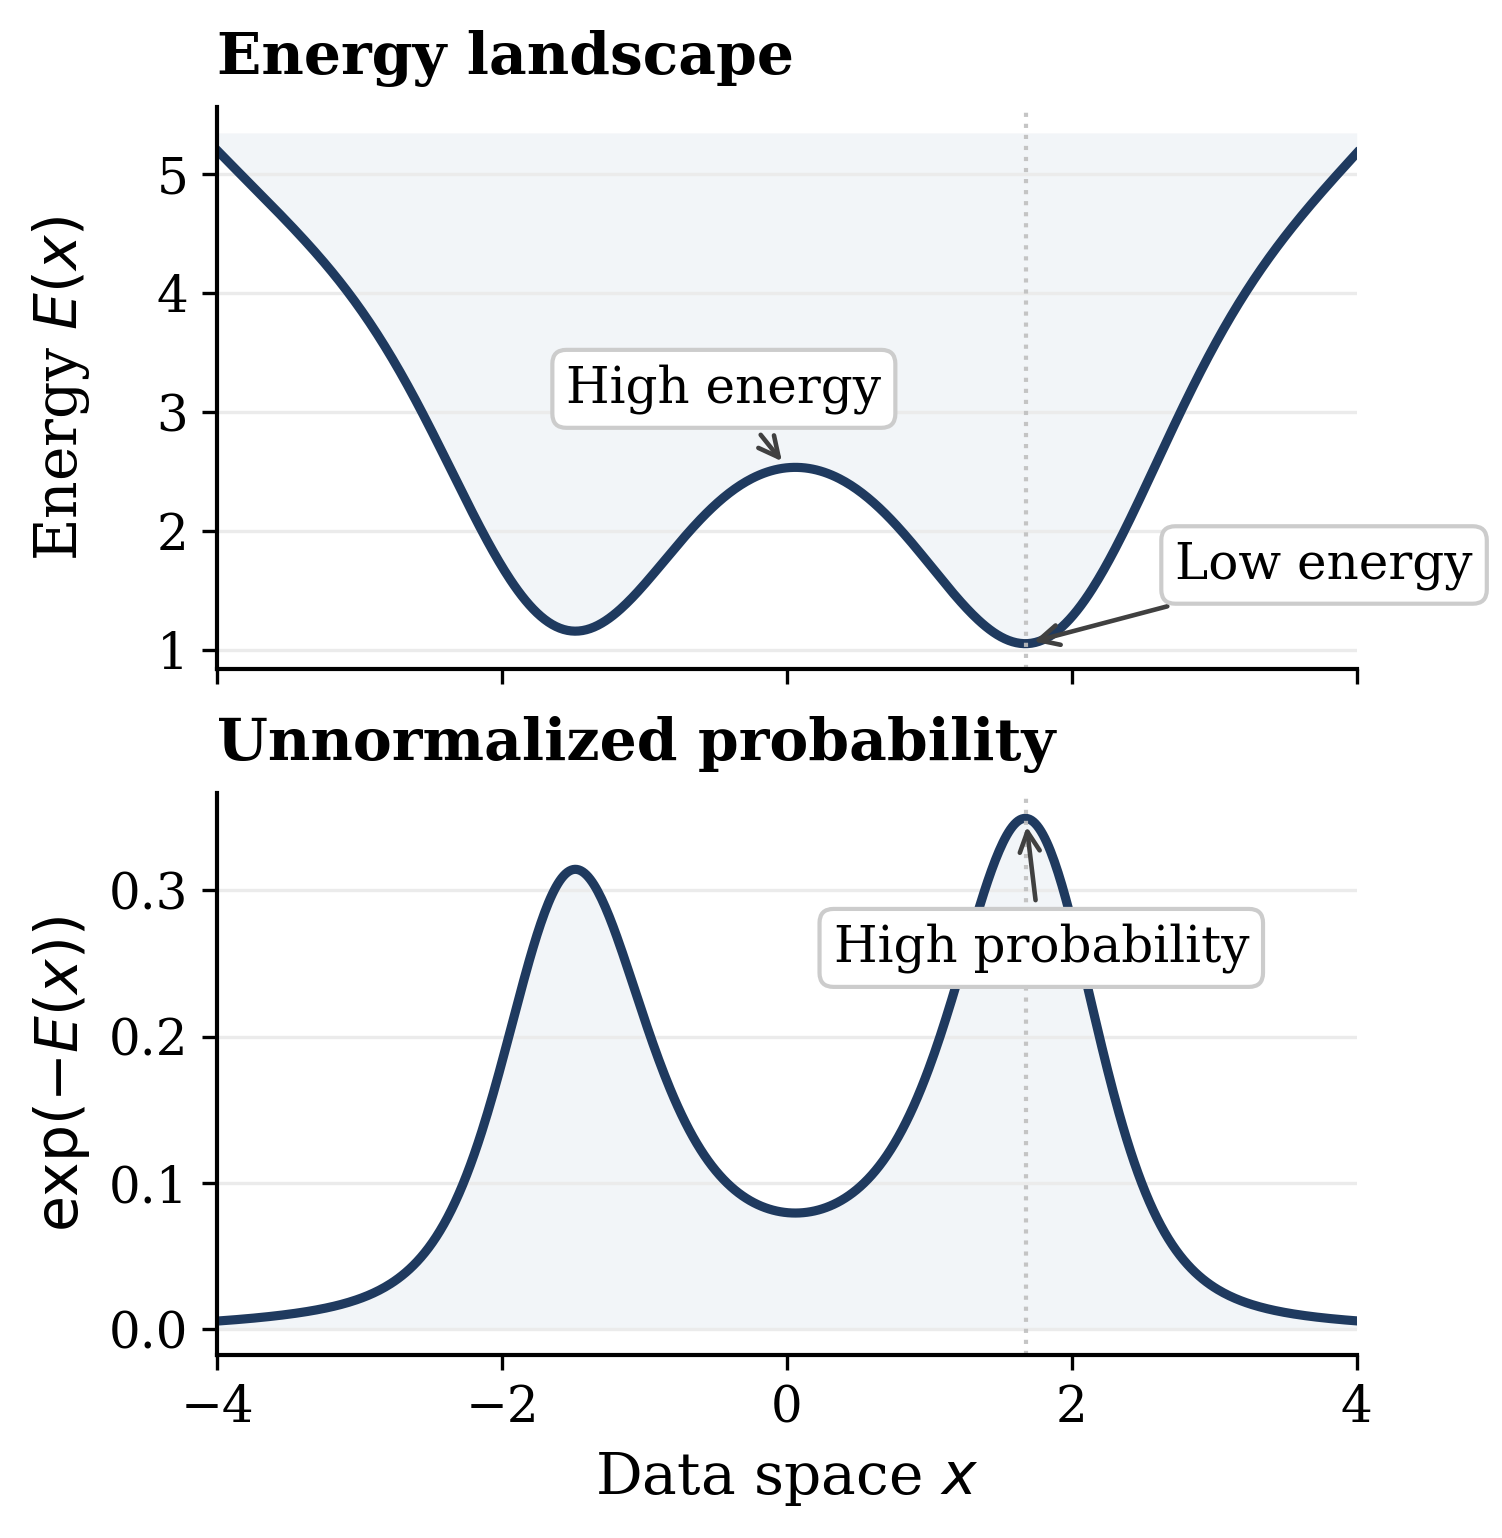

Saved C:\Users\vince\Documents\master\Studium\sem3\RAML\code\ebm-digits\figures\probability_vs_energy.png
Saved C:\Users\vince\Documents\master\Studium\sem3\RAML\code\ebm-digits\figures\probability_vs_energy.pdf


In [1]:
"""Slide figure: From Energy to Probability — E(x) vs exp(-E(x))."""

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Beamer-friendly typography (right column of 16:9 slide)
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 13,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 1.0,
})

# Smooth 1D energy with two valleys (schematic EBM landscape)
def energy(x: np.ndarray) -> np.ndarray:
    return (
        0.15 * x**2
        + 2.8
        - 2.2 * np.exp(-((x - 1.8) ** 2) / 1.1)
        - 2.0 * np.exp(-((x + 1.6) ** 2) / 1.0)
    )


x = np.linspace(-4.0, 4.0, 600)
E = energy(x)
P = np.exp(-E)

# Annotation anchors (right-hand valley / corresponding probability peak)
pos_mask = (x > 0.8) & (x < 2.6)
valley_x = float(x[pos_mask][np.argmin(E[pos_mask])])
valley_y = float(energy(valley_x))

peak_x = float(x[np.argmax(P)])
peak_y = float(np.exp(-energy(peak_x)))

high_x = 0.0
high_y = float(energy(high_x))

# Narrow, tall layout for slide right column
fig, axes = plt.subplots(
    2, 1,
    figsize=(4.9, 5.4),
    dpi=300,
    sharex=True,
    gridspec_kw={"hspace": 0.22},
)

curve_color = "#1f3a5f"
fill_color = "#e9eef3"

# --- Energy ---
ax_e = axes[0]
ax_e.fill_between(x, E, E.max() + 0.15, color=fill_color, alpha=0.55, linewidth=0)
ax_e.plot(x, E, color=curve_color, linewidth=2.2)
ax_e.set_ylabel("Energy $E(x)$")
ax_e.set_title("Energy landscape", loc="left", pad=8, fontweight="bold")
ax_e.annotate(
    "Low energy",
    xy=(valley_x, valley_y),
    xytext=(valley_x + 1.05, valley_y + 0.55),
    fontsize=12,
    arrowprops=dict(arrowstyle="->", color="0.25", lw=1.1),
    bbox=dict(boxstyle="round,pad=0.28", facecolor="white", edgecolor="0.8"),
)
ax_e.annotate(
    "High energy",
    xy=(high_x, high_y),
    xytext=(high_x - 1.55, high_y + 0.55),
    fontsize=12,
    arrowprops=dict(arrowstyle="->", color="0.25", lw=1.1),
    bbox=dict(boxstyle="round,pad=0.28", facecolor="white", edgecolor="0.8"),
)

# --- Probability ---
ax_p = axes[1]
ax_p.fill_between(x, P, color=fill_color, alpha=0.55, linewidth=0)
ax_p.plot(x, P, color=curve_color, linewidth=2.2)
ax_p.set_xlabel("Data space $x$")
ax_p.set_ylabel(r"$\exp(-E(x))$")
ax_p.set_title("Unnormalized probability", loc="left", pad=8, fontweight="bold")
ax_p.annotate(
    "High probability",
    xy=(peak_x, peak_y),
    xytext=(peak_x - 1.35, peak_y * 0.72),
    fontsize=12,
    arrowprops=dict(arrowstyle="->", color="0.25", lw=1.1),
    bbox=dict(boxstyle="round,pad=0.28", facecolor="white", edgecolor="0.8"),
)

# Visual link between corresponding regions
ax_e.axvline(valley_x, color="0.75", linestyle=":", linewidth=1.0, alpha=0.9)
ax_p.axvline(peak_x, color="0.75", linestyle=":", linewidth=1.0, alpha=0.9)

for ax in axes:
    ax.set_xlim(-4.0, 4.0)
    ax.grid(axis="y", color="0.92", linewidth=0.8)

fig.align_ylabels(axes)

out_dir = Path("../figures")
out_dir.mkdir(parents=True, exist_ok=True)
png_path = out_dir / "probability_vs_energy.png"
pdf_path = out_dir / "probability_vs_energy.pdf"

fig.savefig(png_path, bbox_inches="tight", facecolor="white", pad_inches=0.06)
fig.savefig(pdf_path, bbox_inches="tight", facecolor="white", pad_inches=0.06)
plt.show()

print(f"Saved {png_path.resolve()}")
print(f"Saved {pdf_path.resolve()}")

In [ ]:
"""Slide figure: Training Intuition — positive and negative phase (2D contour)."""

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": 15,
        "axes.labelsize": 17,
        "axes.titlesize": 18,
    }
)


def energy_surface(x1: np.ndarray, x2: np.ndarray) -> np.ndarray:
    """Smooth 2D energy with two to three valleys and intervening hills."""
    energy = 0.07 * (x1**2 + x2**2)

    valleys = [
        (1.15, 0.35, 0.52, 2.6),
        (-1.05, -0.85, 0.48, 2.3),
        (-0.25, 1.25, 0.46, 2.1),
    ]
    hills = [
        (0.15, -0.05, 0.34, 1.3),
        (0.55, 0.95, 0.30, 1.1),
    ]

    for cx, cy, width, depth in valleys:
        energy -= depth * np.exp(-((x1 - cx) ** 2 + (x2 - cy) ** 2) / (2 * width**2))

    for cx, cy, width, height in hills:
        energy += height * np.exp(-((x1 - cx) ** 2 + (x2 - cy) ** 2) / (2 * width**2))

    return energy


out_dir = Path("../figures")
out_dir.mkdir(parents=True, exist_ok=True)

x1 = np.linspace(-2.5, 2.5, 300)
x2 = np.linspace(-2.5, 2.5, 300)
X1, X2 = np.meshgrid(x1, x2)
E = energy_surface(X1, X2)

x_real, y_real = 1.05, 0.55
x_model, y_model = 1.85, 1.20

fig, ax = plt.subplots(figsize=(7.2, 6.2), dpi=300, facecolor="white")

cf = ax.contourf(X1, X2, E, levels=28, cmap="Blues_r", antialiased=True)
ax.contour(X1, X2, E, levels=10, colors="white", linewidths=0.45, alpha=0.55)

cbar = fig.colorbar(cf, ax=ax, pad=0.02, fraction=0.046)
cbar.set_label("Energy $E(x)$", fontsize=16, labelpad=10)
cbar.ax.tick_params(labelsize=13)

ax.scatter(
    [x_real],
    [y_real],
    s=160,
    c="#2e7d32",
    edgecolors="white",
    linewidths=1.4,
    zorder=5,
)
ax.scatter(
    [x_model],
    [y_model],
    s=160,
    c="#c0392b",
    edgecolors="white",
    linewidths=1.4,
    zorder=5,
)

label_box = dict(
    boxstyle="round,pad=0.35",
    facecolor="white",
    edgecolor="0.82",
    alpha=0.97,
    linewidth=0.8,
)
label_fs = 15

ax.annotate(
    "Real data",
    xy=(x_real, y_real),
    xytext=(x_real - 1.05, y_real + 0.95),
    fontsize=label_fs,
    color="#2e7d32",
    fontweight="bold",
    ha="center",
    arrowprops=dict(arrowstyle="->", color="#2e7d32", lw=1.4),
    bbox=label_box,
    zorder=6,
)
ax.annotate(
    "",
    xy=(x_real + 0.08, y_real - 0.22),
    xytext=(x_real + 0.08, y_real + 0.12),
    arrowprops=dict(arrowstyle="-|>", color="#2e7d32", lw=2.0, mutation_scale=14),
    zorder=6,
)
ax.text(
    x_real + 0.55,
    y_real - 0.05,
    r"Lower $E(x_{\mathrm{real}})$",
    fontsize=label_fs,
    color="#2e7d32",
    ha="left",
    va="center",
)

ax.annotate(
    "Model sample",
    xy=(x_model, y_model),
    xytext=(x_model + 0.55, y_model + 1.05),
    fontsize=label_fs,
    color="#c0392b",
    fontweight="bold",
    ha="center",
    arrowprops=dict(arrowstyle="->", color="#c0392b", lw=1.4),
    bbox=label_box,
    zorder=6,
)
ax.annotate(
    "",
    xy=(x_model + 0.30, y_model + 0.42),
    xytext=(x_model + 0.06, y_model + 0.08),
    arrowprops=dict(arrowstyle="-|>", color="#c0392b", lw=2.0, mutation_scale=14),
    zorder=6,
)
ax.text(
    x_model + 0.44,
    y_model + 0.56,
    r"Raise $E(x_{\mathrm{model}})$",
    fontsize=label_fs,
    color="#c0392b",
    ha="left",
    va="center",
)

ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
ax.set_title("Training shapes the energy landscape", pad=12, fontweight="bold", color="0.25")
ax.set_aspect("equal")
ax.set_xlim(-2.3, 2.3)
ax.set_ylim(-2.0, 2.0)

for spine in ax.spines.values():
    spine.set_color("0.75")
ax.tick_params(labelsize=13, colors="0.3")

fig.subplots_adjust(left=0.10, right=0.88, top=0.92, bottom=0.10)

png_path = out_dir / "positive_negative_phase.png"
pdf_path = out_dir / "positive_negative_phase.pdf"
fig.savefig(png_path, dpi=300, facecolor="white", bbox_inches="tight", pad_inches=0.05)
fig.savefig(pdf_path, facecolor="white", bbox_inches="tight", pad_inches=0.05)
plt.show()

print(f"Saved {png_path.resolve()}")
print(f"Saved {pdf_path.resolve()}")


In [ ]:
"""Slide figure: Motivation — plausible MNIST digit vs implausible noise."""

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets, transforms

plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": 16,
        "axes.labelsize": 16,
    }
)

rng = np.random.default_rng(42)
out_dir = Path("../figures")
out_dir.mkdir(parents=True, exist_ok=True)

mnist = datasets.MNIST(
    root="../data",
    train=False,
    download=True,
    transform=transforms.ToTensor(),
)
digit_idx = next(i for i, (_, label) in enumerate(mnist) if label == 3)
digit_img, _ = mnist[digit_idx]
digit = digit_img.squeeze().numpy()

noise = rng.uniform(0.0, 1.0, size=digit.shape)

img_w = 0.42
gap = 0.012
bottom = 0.06
height = 0.74
left0 = (1.0 - (2 * img_w + gap)) / 2

fig = plt.figure(figsize=(4.6, 3.2), dpi=300, facecolor="white")
axes = [
    fig.add_axes([left0, bottom, img_w, height]),
    fig.add_axes([left0 + img_w + gap, bottom, img_w, height]),
]
labels = ("Plausible", "Implausible")

for ax, img, label in zip(axes, (digit, noise), labels):
    ax.imshow(img, cmap="gray", vmin=0.0, vmax=1.0, interpolation="nearest")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(label, fontsize=20, fontweight="bold", pad=6)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("0.75")
        spine.set_linewidth(0.8)

png_path = out_dir / "mnist_vs_noise.png"
pdf_path = out_dir / "mnist_vs_noise.pdf"
fig.savefig(png_path, facecolor="white")
fig.savefig(pdf_path, facecolor="white")
plt.show()

print(f"Saved {png_path.resolve()}")
print(f"Saved {pdf_path.resolve()}")


In [ ]:
"""Slide figure: Positive / negative phase — 1D energy curve E(x)."""

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": 15,
        "axes.labelsize": 17,
        "axes.titlesize": 18,
    }
)


def energy_1d(x: np.ndarray) -> np.ndarray:
    """Smooth 1D energy with two valleys and a central hill."""
    energy = 0.12 * x**2 + 1.8
    energy -= 2.4 * np.exp(-((x - 1.35) ** 2) / 0.55)
    energy -= 1.9 * np.exp(-((x + 1.1) ** 2) / 0.50)
    energy += 1.5 * np.exp(-((x - 0.1) ** 2) / 0.35)
    return energy


out_dir = Path("../figures")
out_dir.mkdir(parents=True, exist_ok=True)

x = np.linspace(-2.8, 2.8, 500)
E_curve = energy_1d(x)

# Real data in a valley; model sample on a hill between valleys.
x_real, x_model = 1.02, 0.35
e_real = float(energy_1d(x_real))
e_model = float(energy_1d(x_model))

fig, ax = plt.subplots(figsize=(7.4, 4.8), dpi=300, facecolor="white")
ax.plot(x, E_curve, color="#2f4f6f", lw=2.4, zorder=2)

ax.scatter(
    [x_real],
    [e_real],
    s=140,
    c="#2e7d32",
    edgecolors="white",
    linewidths=1.3,
    zorder=4,
)
ax.scatter(
    [x_model],
    [e_model],
    s=140,
    c="#c0392b",
    edgecolors="white",
    linewidths=1.3,
    zorder=4,
)

label_box = dict(
    boxstyle="round,pad=0.32",
    facecolor="white",
    edgecolor="0.82",
    alpha=0.97,
    linewidth=0.8,
)
label_fs = 14

ax.annotate(
    "Real data",
    xy=(x_real, e_real),
    xytext=(x_real + 0.78, e_real + 0.95),
    fontsize=label_fs,
    color="#2e7d32",
    fontweight="bold",
    ha="center",
    arrowprops=dict(arrowstyle="->", color="#2e7d32", lw=1.3),
    bbox=label_box,
)
ax.annotate(
    "",
    xy=(x_real, e_real - 0.38),
    xytext=(x_real, e_real),
    arrowprops=dict(arrowstyle="-|>", color="#2e7d32", lw=2.0, mutation_scale=13),
)
ax.text(
    x_real + 0.48,
    e_real + 0.22,
    r"Lower $E(x_{\mathrm{real}})$",
    fontsize=label_fs,
    color="#2e7d32",
    ha="left",
)

ax.annotate(
    "Model sample",
    xy=(x_model, e_model),
    xytext=(x_model - 1.05, e_model - 0.38),
    fontsize=label_fs,
    color="#c0392b",
    fontweight="bold",
    ha="center",
    arrowprops=dict(arrowstyle="->", color="#c0392b", lw=1.3),
    bbox=label_box,
)
ax.annotate(
    "",
    xy=(x_model, e_model + 0.55),
    xytext=(x_model, e_model + 0.03),
    arrowprops=dict(arrowstyle="-|>", color="#c0392b", lw=2.0, mutation_scale=13),
)
ax.text(
    x_model - 0.95,
    e_model + 0.38,
    r"Raise $E(x_{\mathrm{model}})$",
    fontsize=label_fs,
    color="#c0392b",
    ha="right",
)

ax.set_xlabel("Data $x$")
ax.set_ylabel("Energy $E(x)$")
ax.set_title("Training shapes the energy landscape", pad=10, fontweight="bold", color="0.25")
ax.set_xlim(-2.8, 2.8)
ax.set_ylim(E_curve.min() - 0.15, E_curve.max() + 0.35)
ax.grid(axis="y", color="0.92", linewidth=0.8)

for spine in ax.spines.values():
    spine.set_color("0.75")
ax.tick_params(labelsize=13, colors="0.3")

fig.subplots_adjust(left=0.11, right=0.97, top=0.90, bottom=0.14)

png_path = out_dir / "positive_negative_phase_1d.png"
pdf_path = out_dir / "positive_negative_phase_1d.pdf"
fig.savefig(png_path, dpi=300, facecolor="white", bbox_inches="tight", pad_inches=0.05)
fig.savefig(pdf_path, facecolor="white", bbox_inches="tight", pad_inches=0.05)
plt.show()

print(f"Saved {png_path.resolve()}")
print(f"Saved {pdf_path.resolve()}")


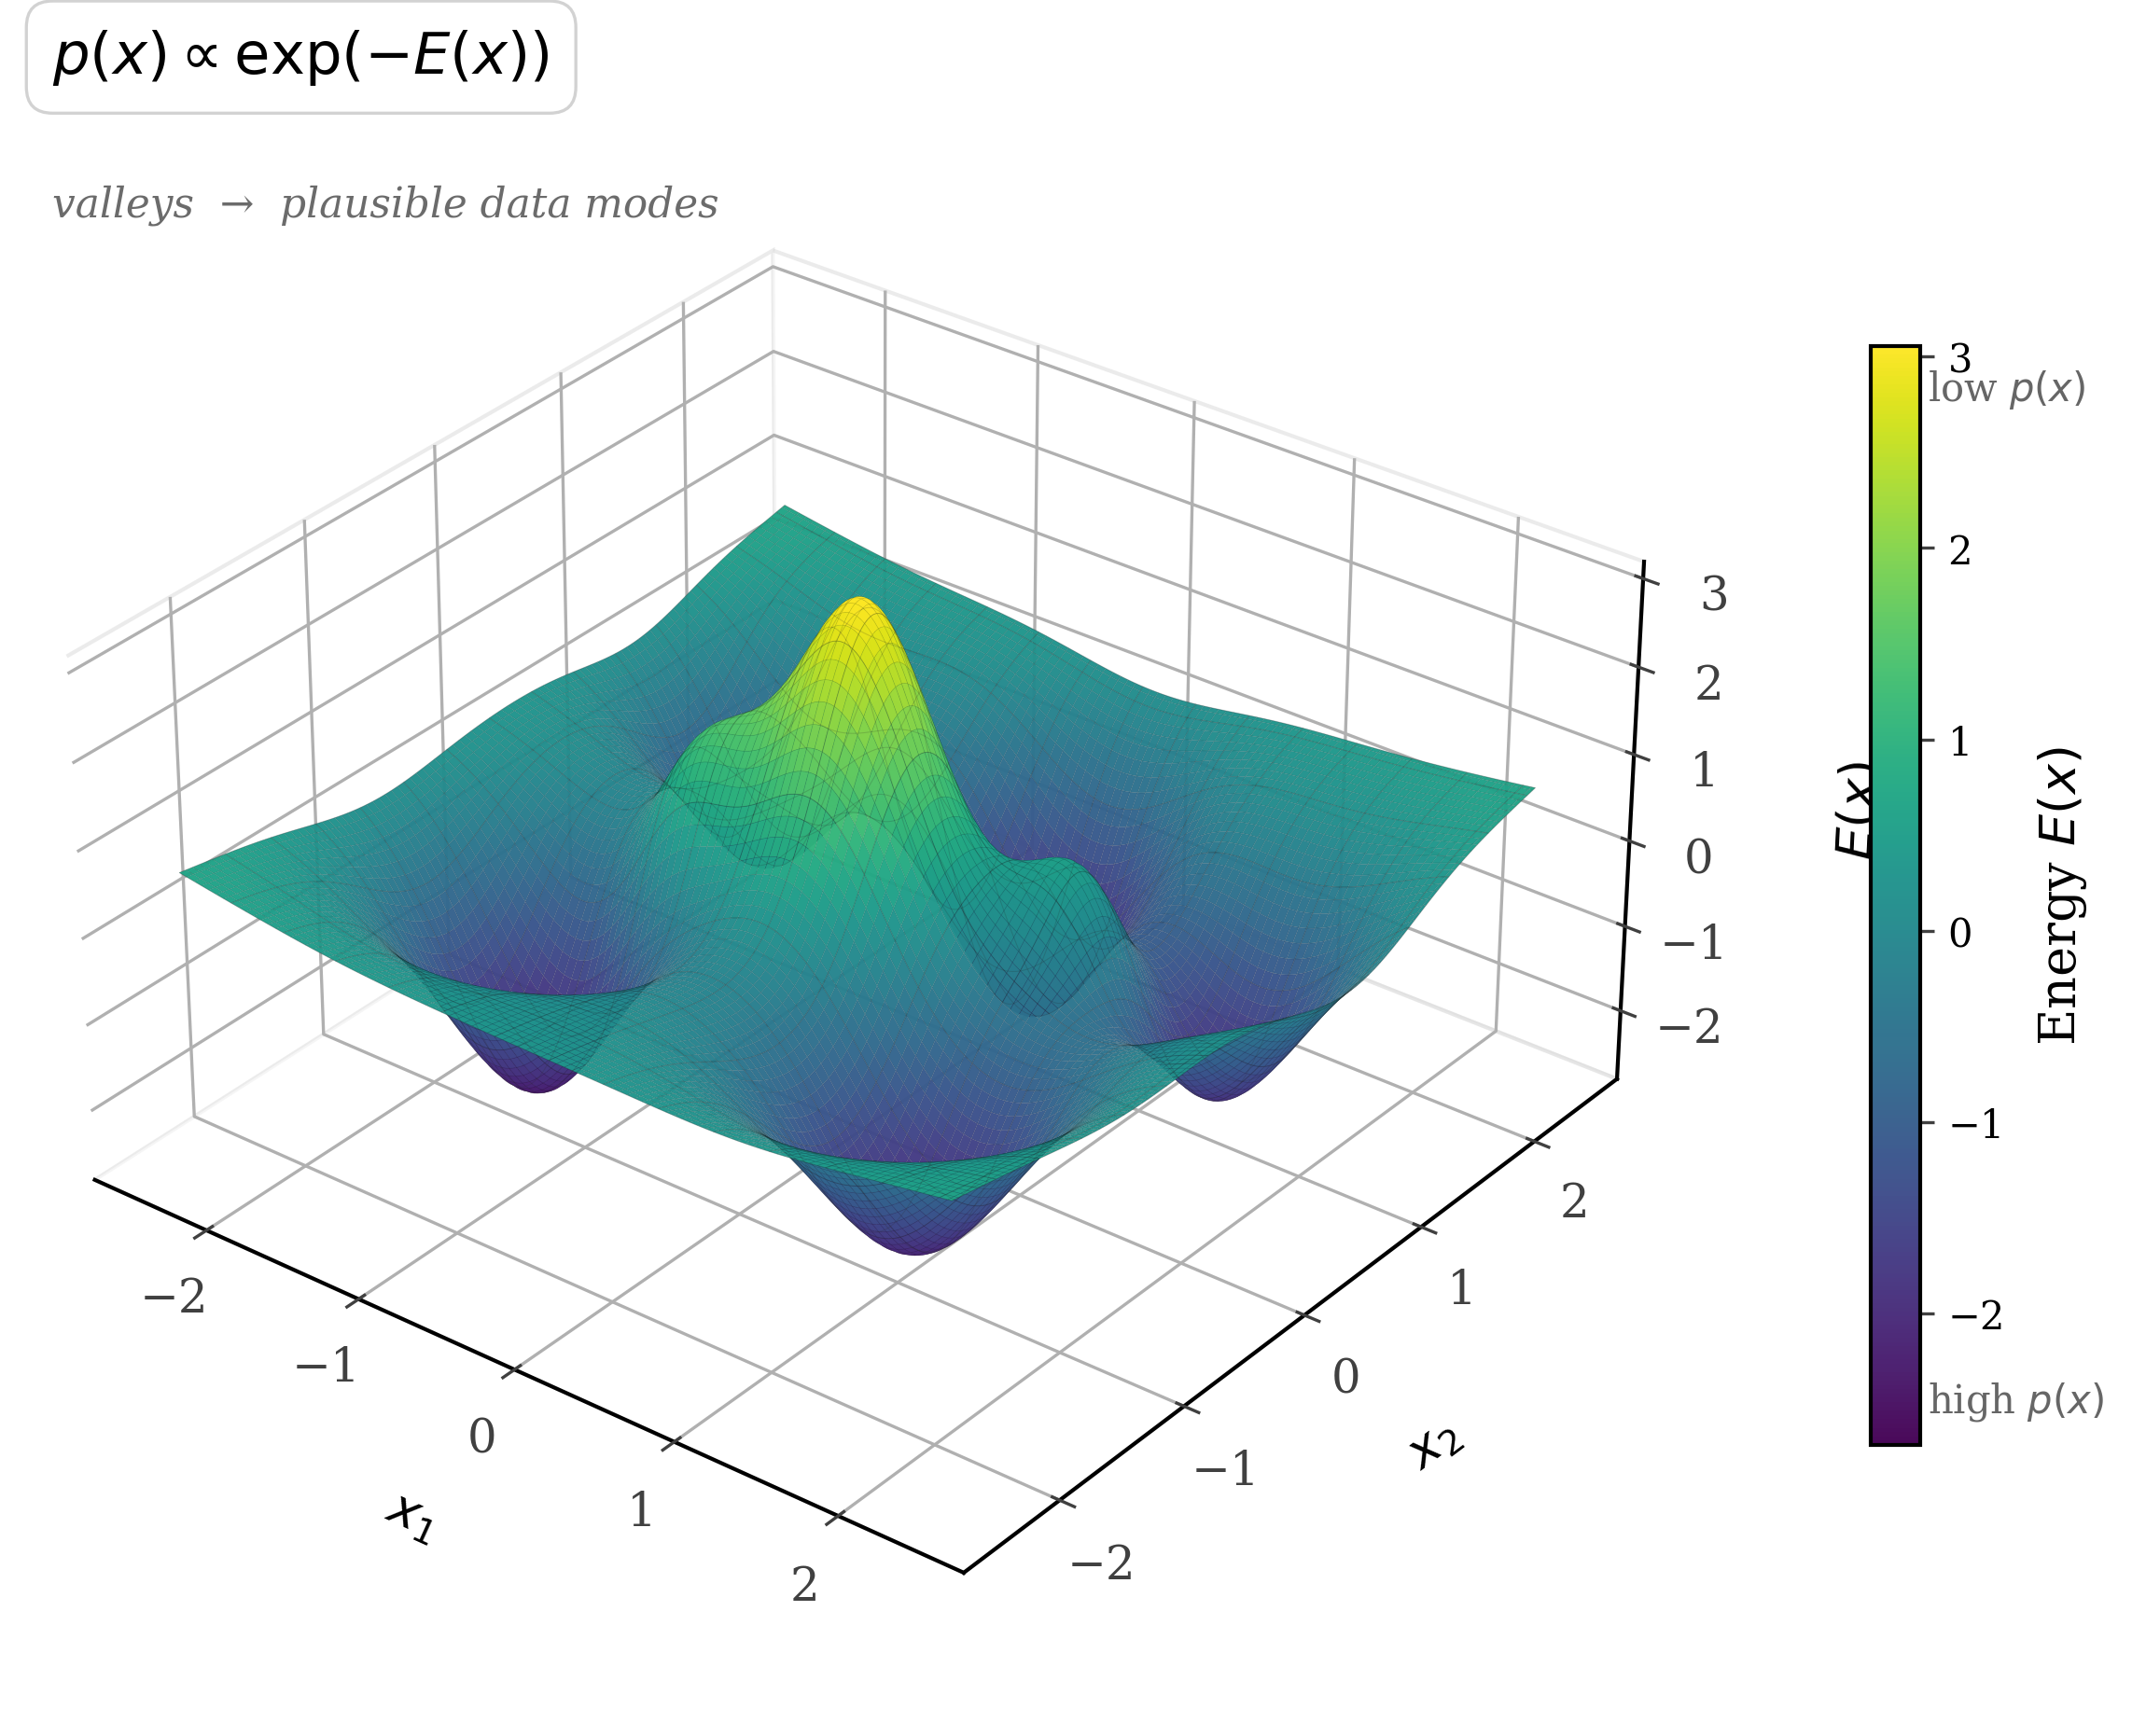

Saved C:\Users\vince\Documents\master\Studium\sem3\RAML\code\ebm-digits\figures\showcase_figure.png
Saved C:\Users\vince\Documents\master\Studium\sem3\RAML\code\ebm-digits\figures\showcase_figure.pdf


In [19]:
"""Title slide: 3D energy landscape E(x1, x2)."""

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": 12,
        "axes.labelsize": 13,
    }
)


def energy_surface(x1: np.ndarray, x2: np.ndarray) -> np.ndarray:
    """Smooth synthetic energy with valleys (minima) and hills (maxima)."""
    energy = 0.06 * (x1**2 + x2**2)

    valleys = [
        (-1.35, -0.95, 0.48, 2.6),
        (1.15, -1.05, 0.52, 2.4),
        (0.05, 1.35, 0.46, 2.8),
        (-1.55, 1.15, 0.42, 2.1),
        (1.55, 0.85, 0.50, 2.3),
    ]
    hills = [
        (0.0, 0.0, 0.38, 2.2),
        (-0.25, 0.35, 0.32, 1.6),
        (1.0, 0.55, 0.28, 1.4),
        (-0.9, -0.2, 0.30, 1.5),
    ]

    for cx, cy, width, depth in valleys:
        energy -= depth * np.exp(-((x1 - cx) ** 2 + (x2 - cy) ** 2) / (2 * width**2))

    for cx, cy, width, height in hills:
        energy += height * np.exp(-((x1 - cx) ** 2 + (x2 - cy) ** 2) / (2 * width**2))

    return energy


out_dir = Path("../figures")
out_dir.mkdir(parents=True, exist_ok=True)

x1 = np.linspace(-2.4, 2.4, 200)
x2 = np.linspace(-2.4, 2.4, 200)
X1, X2 = np.meshgrid(x1, x2)
E = energy_surface(X1, X2)

fig = plt.figure(figsize=(8.8, 6.6), dpi=300, facecolor="white")
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    X1,
    X2,
    E,
    cmap="viridis",
    linewidth=0.15,
    edgecolor=(0, 0, 0, 0.12),
    antialiased=True,
    rstride=2,
    cstride=2,
    alpha=0.97,
)
ax.plot_wireframe(
    X1,
    X2,
    E,
    rstride=14,
    cstride=14,
    color="0.15",
    linewidth=0.25,
    alpha=0.18,
)

ax.set_xlabel(r"$x_1$", labelpad=10)
ax.set_ylabel(r"$x_2$", labelpad=10)
ax.set_zlabel(r"$E(x)$", labelpad=12)
ax.view_init(elev=31, azim=-52)

ax.set_box_aspect((1, 1, 0.55))
ax.set_xticks(np.arange(-2, 3, 1))
ax.set_yticks(np.arange(-2, 3, 1))

for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
    axis.pane.set_facecolor((1, 1, 1, 0))
    axis.pane.set_edgecolor("0.85")

ax.grid(True, color="0.88", linewidth=0.6, alpha=0.7)
ax.tick_params(colors="0.25", pad=2)

cbar = fig.colorbar(surf, ax=ax, shrink=0.62, pad=0.10, aspect=22)
cbar.set_label(r"Energy $E(x)$", labelpad=8)
cbar.ax.tick_params(labelsize=10, color="0.25")
cbar.ax.text(
    1.15,
    0.02,
    r"high $p(x)$",
    transform=cbar.ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=10,
    color="0.40",
)
cbar.ax.text(
    1.15,
    0.98,
    r"low $p(x)$",
    transform=cbar.ax.transAxes,
    ha="left",
    va="top",
    fontsize=10,
    color="0.40",
)

formula_box = dict(
    boxstyle="round,pad=0.45",
    facecolor="white",
    edgecolor="0.82",
    alpha=0.96,
    linewidth=0.8,
)
ebm_formula = r"$p(x) \propto \exp\!\left(-E(x)\right)$"
fig.text(0.03, 0.97, ebm_formula, ha="left", va="top", fontsize=15, bbox=formula_box)
fig.text(
    0.03,
    0.885,
    "valleys  \u2192  plausible data modes",
    ha="left",
    va="top",
    fontsize=10.5,
    color="0.42",
    style="italic",
)

fig.subplots_adjust(left=0.02, right=0.90, top=0.98, bottom=0.02)

png_path = out_dir / "showcase_figure.png"
pdf_path = out_dir / "showcase_figure.pdf"
fig.savefig(png_path, dpi=300, facecolor="white", bbox_inches="tight", pad_inches=0.05)
fig.savefig(pdf_path, facecolor="white", bbox_inches="tight", pad_inches=0.05)
plt.show()

print(f"Saved {png_path.resolve()}")
print(f"Saved {pdf_path.resolve()}")


In [ ]:
"""Slide figure: Modern Relevance — Why EBMs Still Matter (flow diagram)."""

from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": 14,
        "figure.facecolor": "white",
        "savefig.facecolor": "white",
    }
)

C_CENTER = "#e8f0f8"
C_CENTER_E = "#2f4f6f"
C_NODE = "#f7f7f7"
C_NODE_E = "#5a5a5a"
ARROW = "#3d3d3d"


def rounded_box(
    ax,
    xy: tuple[float, float],
    width: float,
    height: float,
    text: str,
    facecolor: str,
    edgecolor: str,
    fontsize: float = 15,
    weight: str = "normal",
) -> FancyBboxPatch:
    x, y = xy
    patch = FancyBboxPatch(
        (x, y),
        width,
        height,
        boxstyle="round,pad=0.02,rounding_size=0.15",
        facecolor=facecolor,
        edgecolor=edgecolor,
        linewidth=1.8,
        zorder=2,
    )
    ax.add_patch(patch)
    ax.text(
        x + width / 2,
        y + height / 2,
        text,
        ha="center",
        va="center",
        fontsize=fontsize,
        fontweight=weight,
        zorder=3,
        linespacing=1.2,
    )
    return patch


def flow_arrow(ax, start: tuple[float, float], end: tuple[float, float]) -> None:
    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="-|>",
        mutation_scale=16,
        linewidth=1.6,
        color=ARROW,
        shrinkA=6,
        shrinkB=6,
        connectionstyle="arc3,rad=0.0",
        zorder=1,
    )
    ax.add_patch(arrow)


out_dir = Path("../figures")
out_dir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(12.8, 7.2), dpi=300)
ax.set_xlim(0, 16)
ax.set_ylim(0, 9)
ax.axis("off")

ebm_width, ebm_height = 4.6, 1.6
ebm_x, ebm_y = 1.8, 3.85
rounded_box(
    ax,
    (ebm_x, ebm_y),
    ebm_width,
    ebm_height,
    "Energy-Based\nModels",
    C_CENTER,
    C_CENTER_E,
    fontsize=17,
    weight="bold",
)
ebm_anchor = (ebm_x + ebm_width, ebm_y + ebm_height / 2)

node_width, node_height = 4.8, 1.25
node_x = 9.8
modern_topics = [
    "Score-Based\nModels",
    "Diffusion\nModels",
    "Energy-Based\nTransformers",
]
node_ys = [6.0, 3.85, 1.7]

for label, node_y in zip(modern_topics, node_ys):
    rounded_box(
        ax,
        (node_x, node_y),
        node_width,
        node_height,
        label,
        C_NODE,
        C_NODE_E,
        fontsize=15,
        weight="semibold",
    )
    node_anchor = (node_x, node_y + node_height / 2)
    flow_arrow(ax, ebm_anchor, node_anchor)

fig.subplots_adjust(left=0.02, right=0.98, top=0.96, bottom=0.04)

png_path = out_dir / "modern_relevance_diagram.png"
pdf_path = out_dir / "modern_relevance_diagram.pdf"
fig.savefig(png_path, dpi=300, facecolor="white", bbox_inches="tight", pad_inches=0.06)
fig.savefig(pdf_path, facecolor="white", bbox_inches="tight", pad_inches=0.06)
plt.show()

print(f"Saved {png_path.resolve()}")
print(f"Saved {pdf_path.resolve()}")
